# Pre-processing

This notebook is the pre-processor. It reads the videos and converts them into face crop tensors so that the other notebooks do not replicate the process.

The whole pre-processing pipeline can be summarized as:

- Decode the video.
- Sample 24 frames evenly across the video.
- For each frame, detect the largest face.
- Crop the face region (with margin) and resize to 224×224.
- Stack into a tensor of shape `[24, 3, 224, 224]` and save as `.pt`.

## 1. Set up

In [1]:
# Import necessary libraries
import json
import random
from pathlib import Path
from typing import List, Optional

import numpy as np
import torch
from decord import VideoReader, cpu
from facenet_pytorch import MTCNN
from PIL import Image
from tqdm.auto import tqdm

In [2]:
SEED = 42

# Set the seed value
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(42)

In [3]:
# Set the device
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"GPU Name is:{torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"

GPU Name is:NVIDIA GeForce RTX 5080


In [4]:
# Set the directory paths
DATASET_DIR_PATH = Path("dataset/FaceForensics++_C23")
OUTPUT_DIR_PATH = Path("dataset/ff-c23-preprocessed")


OUTPUT_DIR_PATH.mkdir(parents=True, exist_ok=True)

# Subset size
# VIDEOS_PER_CLASS = 50 # For dry-run
VIDEOS_PER_CLASS = 700

# Held-out class size
VIDEOS_FOR_HELDOUT = 400

# Specify class names
TRAINING_CLASSES = ["original", "Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
HELDOUT_CLASS = "FaceShifter"
ALL_CLASSES = TRAINING_CLASSES + [HELDOUT_CLASS]



In [5]:
# --- Frame sampling ---
FRAMES_PER_CLIP = 24 # Number of frames sampled from each video
FACE_CROP_SIZE = 224 # Final face crop size (square)
FACE_MARGIN_RATIO = 0.3 # Extra context around detected face box (30%)

## 2. Load the face detector

We will use `facenet-pytorch` for detecting the face.

In [6]:
face_detector = MTCNN(
    image_size=FACE_CROP_SIZE,
    margin=0,
    keep_all=False, # Keep only the most confident face per frame
    post_process=False, # Return uint8 tensors, not normalized floats
    device=DEVICE,
)

## 3. Helper functions

The whole pre-processing pipeline is divided into small modular functions.

In [7]:
def sample_evenly_spaced_frame_indices(total_frame_count: int, num_frames_wanted: int) -> List[int]:
    """
    This function return num_frames_wanted indices spread evenly across a video.
    """
    if total_frame_count <= num_frames_wanted:
        # It is a short. So we take every frame and pad by repeating the last one
        indices = list(range(total_frame_count))
        while len(indices) < num_frames_wanted:
            indices.append(total_frame_count - 1)
        return indices
    return np.linspace(0, total_frame_count - 1, num=num_frames_wanted, dtype=int).tolist()

def read_frames_from_video(video_path: Path, frame_indices: List[int]):
    """
    This function loads specified frames from a video. And returns an array of shape [N, H, W, 3] uint8.
    """
    try:
        video_reader = VideoReader(str(video_path), ctx=cpu(0))
        frames_batch = video_reader.get_batch(frame_indices).asnumpy()
        return frames_batch
    except Exception as e:
        print(f"An error occured while decoding '{video_path.name}' video ... skipping it:\n{str(e)}")
        return None


def crop_face_with_margin(frame_rgb: np.ndarray, face_box: np.ndarray, margin_ratio: float) -> np.ndarray:
    """
    This function crops extra margins around a face based on the input boundingbox [x1, y1, x2, y2].
    """
    frame_height, frame_width = frame_rgb.shape[:2]
    x1, y1, x2, y2 = face_box
    box_width = x2 - x1
    box_height = y2 - y1
    
    margin_x = box_width * margin_ratio
    margin_y = box_height * margin_ratio
    
    # Expand the box but clip to image bounds
    x1_expanded = max(0, int(x1 - margin_x))
    y1_expanded = max(0, int(y1 - margin_y))
    x2_expanded = min(frame_width, int(x2 + margin_x))
    y2_expanded = min(frame_height, int(y2 + margin_y))
    
    return frame_rgb[y1_expanded:y2_expanded, x1_expanded:x2_expanded]


def resize_to_square(image_rgb: np.ndarray, target_size: int) -> np.ndarray:
    """
    This function resizes an RGB image to (target_size, target_size).
    """
    pil_image = Image.fromarray(image_rgb)
    pil_resized = pil_image.resize((target_size, target_size), Image.BILINEAR)
    return np.array(pil_resized)


def detect_faces_for_batch(frames_rgb_uint8: np.ndarray):
    """
    This function detects the faces using MTCNN on a batch of frames. 
    """
    pil_frames = [Image.fromarray(frame) for frame in frames_rgb_uint8]
    # MTCNN.detect returns (boxes, probs); boxes is array of shape [k, 4] per image or None.
    boxes_per_frame, _ = face_detector.detect(pil_frames)
    
    largest_box_per_frame = []
    for boxes_for_this_frame in boxes_per_frame:
        if boxes_for_this_frame is None or len(boxes_for_this_frame) == 0:
            largest_box_per_frame.append(None)
            continue
        # We select the box with the largest area
        box_areas = [(box[2] - box[0]) * (box[3] - box[1]) for box in boxes_for_this_frame]
        largest_index = int(np.argmax(box_areas))
        largest_box_per_frame.append(boxes_for_this_frame[largest_index])
    
    return largest_box_per_frame

## 4. Process a single video

This is the core function that utilizes the aforedefined helper functions. For a given a video path, it returns the final `[24, 3, 224, 224]` tensor or `None` on failure.

In [8]:
def process_single_video(video_path: Path):
    """
    Thius function accepts the video path, converts it to a tensor clip of cropped, resized face frames.
    """
    # Step 1: figure out which frame indices to sample
    try:
        video_reader = VideoReader(str(video_path), ctx=cpu(0))
        total_frames = len(video_reader)
    except Exception as e:
        print(f"An error occured while opening '{video_path.name}' video ... skipping it:\n{str(e)}")
        return None
    
    frame_indices_to_sample = sample_evenly_spaced_frame_indices(total_frames, FRAMES_PER_CLIP)
    
    # Step 2: load the frames into memory
    sampled_frames = read_frames_from_video(video_path, frame_indices_to_sample)
    if sampled_frames is None:
        return None
    
    # Step 3: detect a face in each frame using MTCNN
    face_boxes = detect_faces_for_batch(sampled_frames)
    
    # Step 4: crop + resize each frame
    cropped_resized_frames = []
    last_valid_box = None
    for frame_rgb, face_box in zip(sampled_frames, face_boxes):
        if face_box is None:
            face_box = last_valid_box
        else:
            last_valid_box = face_box
        
        if face_box is None:
            # NBo face detected in this video. so we should skip it
            return None
        
        face_crop = crop_face_with_margin(frame_rgb, face_box, FACE_MARGIN_RATIO)
        if face_crop.size == 0:
            return None
        face_crop_resized = resize_to_square(face_crop, FACE_CROP_SIZE)
        cropped_resized_frames.append(face_crop_resized)
    
    # Step 5: stack into a tensor of shape [T, H, W, C] uint8, then rearrange to [T, C, H, W] float16.
    clip_array = np.stack(cropped_resized_frames, axis=0) # [T, H, W, 3] uint8
    clip_tensor = torch.from_numpy(clip_array).permute(0, 3, 1, 2) # [T, 3, H, W] uint8
    clip_tensor = clip_tensor.to(torch.float16) / 255.0# normalize to [0, 1]
    return clip_tensor

## 5. Collect the videos to process

For each class, we take the first N video files sorted alphabetically. This will make this selection reproducible across runs.

In [9]:
def find_video_files_for_class(class_name: str):
    """
    This function returns a sorted list of all .mp4 files for a class.
    """
    class_folder = DATASET_DIR_PATH / class_name
    return sorted(class_folder.rglob("*.mp4"))

videos_to_process_by_class = {}
for class_name in ALL_CLASSES:
    all_videos_for_this_class = find_video_files_for_class(class_name)
    target_count = VIDEOS_FOR_HELDOUT if class_name == HELDOUT_CLASS else VIDEOS_PER_CLASS
    selected_videos = all_videos_for_this_class[:target_count]
    videos_to_process_by_class[class_name] = selected_videos
    print(f"'{class_name}' found {len(all_videos_for_this_class)} videos, and selected {len(selected_videos)}")

'original' found 1000 videos, and selected 700
'Deepfakes' found 1000 videos, and selected 700
'Face2Face' found 1000 videos, and selected 700
'FaceSwap' found 1000 videos, and selected 700
'NeuralTextures' found 1000 videos, and selected 700
'FaceShifter' found 1000 videos, and selected 400


## 6. Run the preprocessing pipeline

For each class, process each video and save the resulting tensor to `OUTPUT_DIR_PATH`.

In [10]:
processing_stats = {class_name: {"saved": 0, "failed": 0} for class_name in ALL_CLASSES}

for class_name, video_paths in videos_to_process_by_class.items():
    output_class_folder = OUTPUT_DIR_PATH / class_name
    output_class_folder.mkdir(parents=True, exist_ok=True)
    
    print(f"\n--- Processing class: {class_name} ---")
    for video_path in tqdm(video_paths, desc=class_name):
        output_tensor_path = output_class_folder / f"{video_path.stem}.pt"
        
        clip_tensor = process_single_video(video_path)
        if clip_tensor is None:
            processing_stats[class_name]["failed"] += 1
            continue
        
        torch.save(clip_tensor, output_tensor_path)
        processing_stats[class_name]["saved"] += 1

print("\n=== Preprocessing summary ===")
for class_name, stats in processing_stats.items():
    print(f"  {class_name} saved={stats['saved']}  failed={stats['failed']}")


--- Processing class: original ---


original:   0%|          | 0/700 [00:00<?, ?it/s]


--- Processing class: Deepfakes ---


Deepfakes:   0%|          | 0/700 [00:00<?, ?it/s]


--- Processing class: Face2Face ---


...


--- Processing class: NeuralTextures ---


NeuralTextures:   0%|          | 0/700 [00:00<?, ?it/s]


--- Processing class: FaceShifter ---


FaceShifter:   0%|          | 0/400 [00:00<?, ?it/s]


=== Preprocessing summary ===
  original saved=700  failed=0
  Deepfakes saved=699  failed=1
  Face2Face saved=700  failed=0
  FaceSwap saved=700  failed=0
  NeuralTextures saved=700  failed=0
  FaceShifter saved=400  failed=0


## 7. Build train/val/test split files

We split each class 80/10/10 (train/val/test). FaceShifter is stored entirely into a separate `heldout` group used only for the cross-manipulation generalization test.

Splits are saved as JSON for the training notebooks.

In [11]:
SPLIT_RATIOS = {"train": 0.80, "validation": 0.10, "test": 0.10}

def assign_split_for_index(index: int, total: int) -> str:
    """
    This function gives the indices for split based on position in sorted list.
    """
    train_cutoff = int(total * SPLIT_RATIOS["train"])
    validation_cutoff = train_cutoff + int(total * SPLIT_RATIOS["validation"])
    if index < train_cutoff:
        return "train"
    elif index < validation_cutoff:
        return "validation"
    else:
        return "test"

splits_dict = {"train": [], "validation": [], "test": [], "heldout": []}

for class_name in ALL_CLASSES:
    output_class_folder = OUTPUT_DIR_PATH / class_name
    tensor_files_in_class = sorted(output_class_folder.glob("*.pt"))
    
    if class_name == HELDOUT_CLASS:
        # FaceShifter, which is held out entirely for generalization testing
        for tensor_file in tensor_files_in_class:
            splits_dict["heldout"].append({
                "tensor_path": str(tensor_file.relative_to(OUTPUT_DIR_PATH)).replace("\\", "/"),
                "class_name": class_name,
                "label": 1,  # FaceShifter is a fake
            })
        continue
    
    # All other classes get split into train / validation / test
    binary_label = 0 if class_name == "original" else 1
    for file_index, tensor_file in enumerate(tensor_files_in_class):
        which_split = assign_split_for_index(file_index, len(tensor_files_in_class))
        splits_dict[which_split].append({
            "tensor_path": str(tensor_file.relative_to(OUTPUT_DIR_PATH)).replace("\\", "/"),
            "class_name": class_name,
            "label": binary_label,
        })

# Save splits as JSON.
splits_json_path = OUTPUT_DIR_PATH / "splits.json"
with open(splits_json_path, "w") as f:
    json.dump(splits_dict, f, indent=2)

print("Split sizes:")
for split_name, entries in splits_dict.items():
    print(f"  {split_name} {len(entries)} clips")
print(f"\nSaved splits to {splits_json_path}")

Split sizes:
  train 2799 clips
  validation 349 clips
  test 351 clips
  heldout 400 clips

Saved splits to dataset\ff-c23-preprocessed\splits.json


## 8. Visual sanity check

Load one saved tensor for each class and display 8 of its 24 frames.

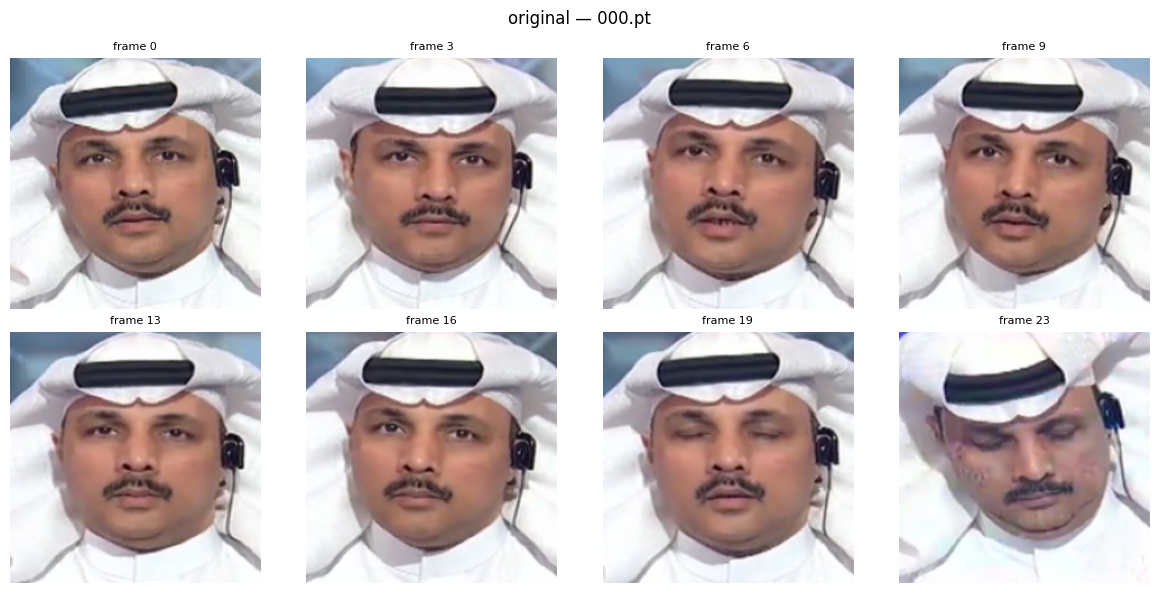

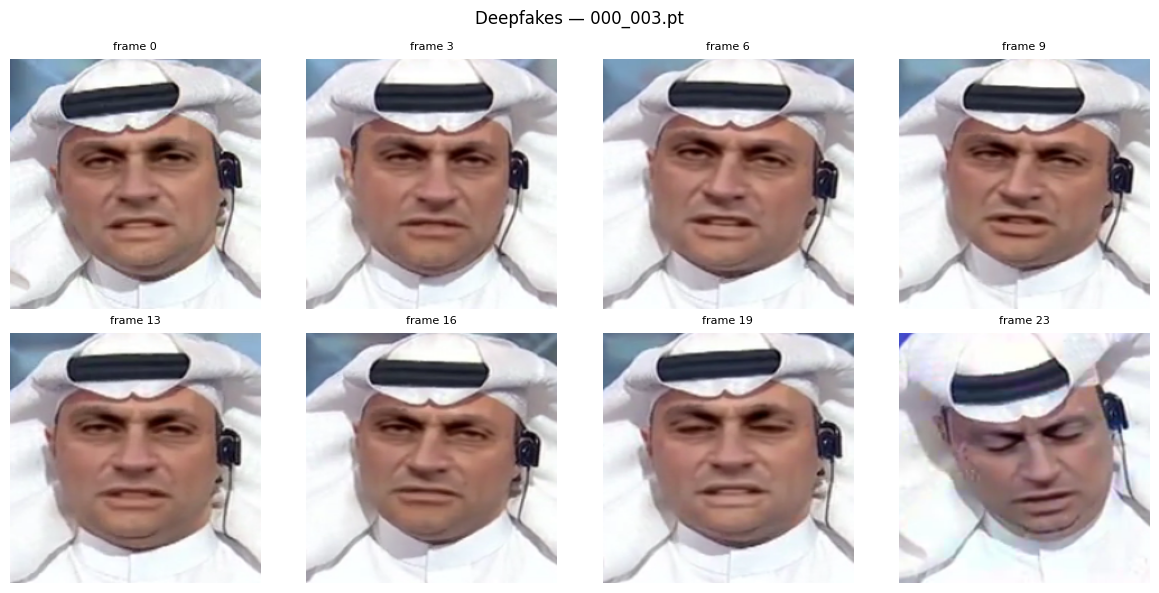

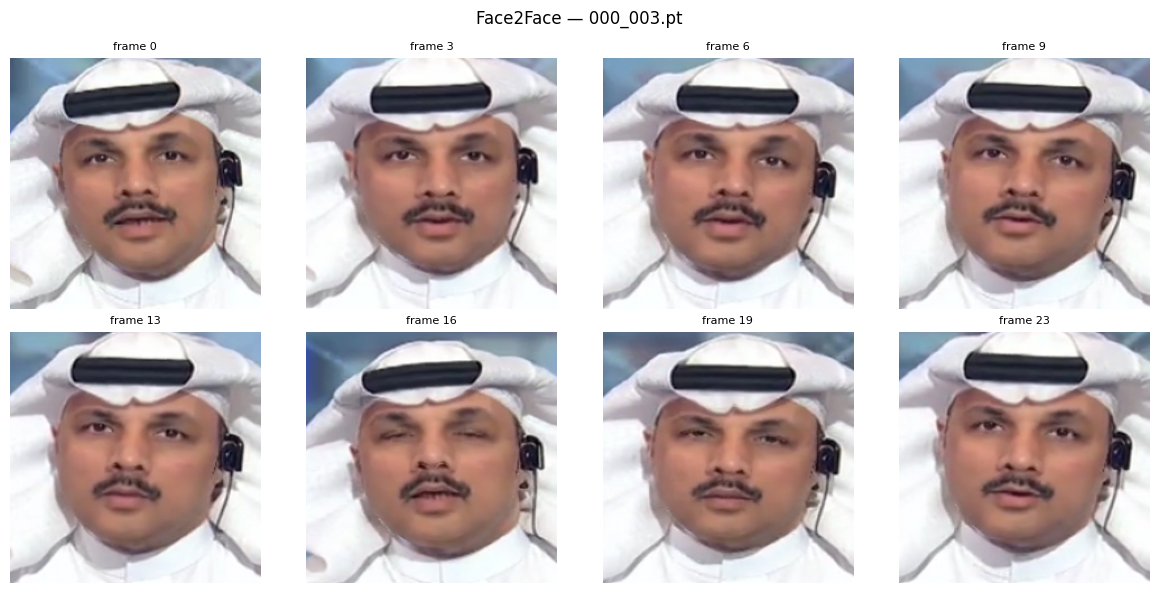

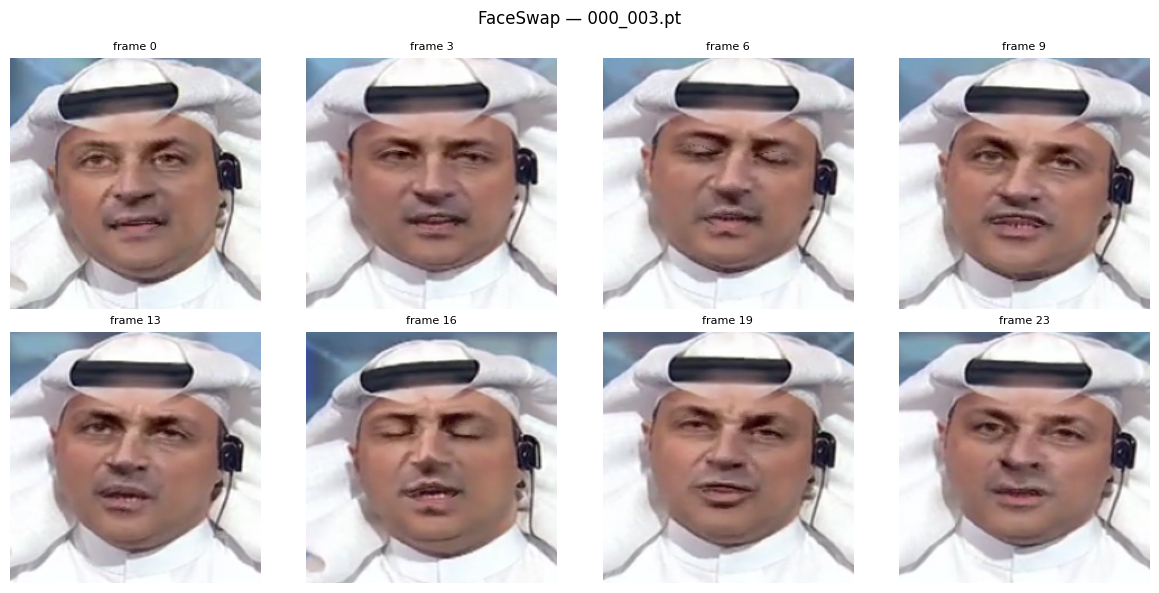

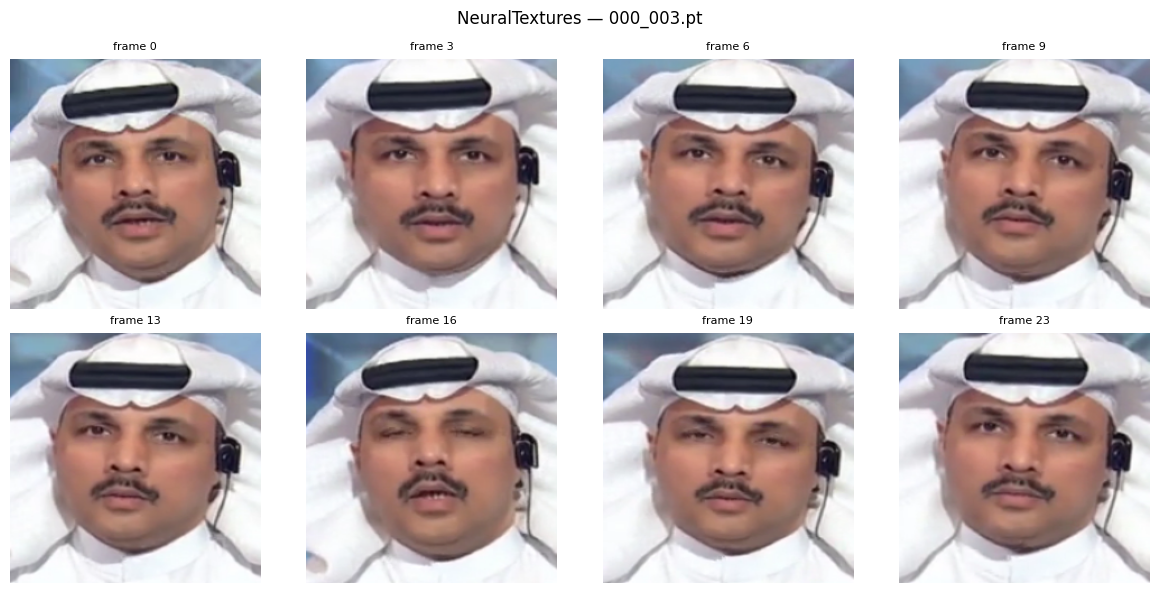

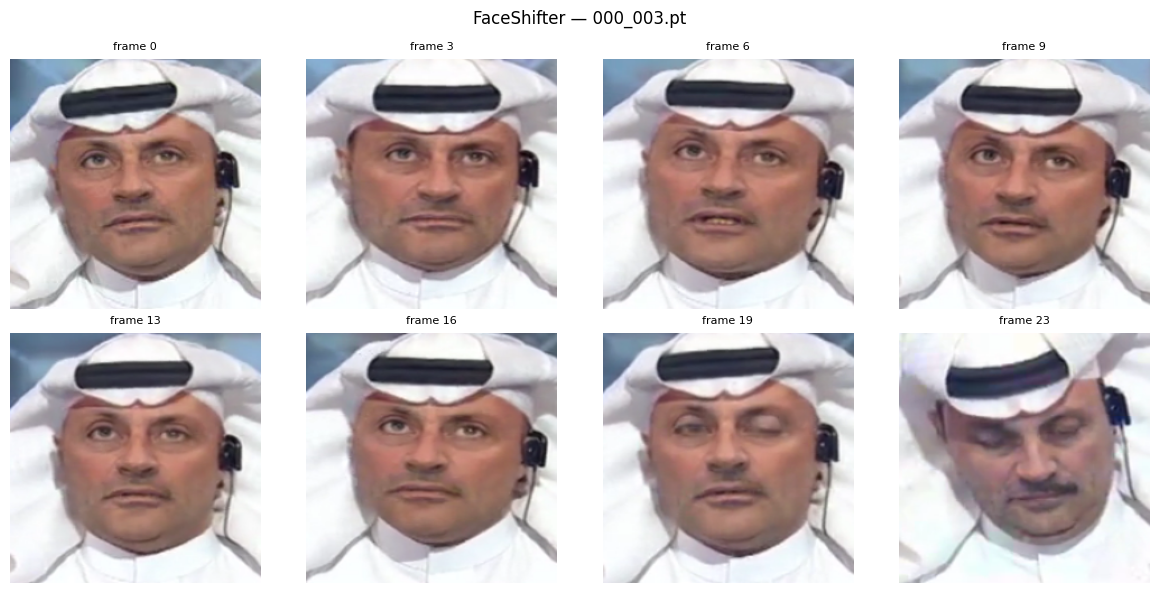

In [12]:
import matplotlib.pyplot as plt

def visualize_clip_tensor(tensor_path: Path, title: str):
    """
    This function displays 8 evenly-sampled frames of a saved clip
    """
    clip_tensor = torch.load(tensor_path).float()  # [24, 3, 224, 224]
    num_frames_total = clip_tensor.shape[0]
    frame_indices_to_show = np.linspace(0, num_frames_total - 1, 8, dtype=int)
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle(title, fontsize=12)
    for plot_pos, frame_idx in enumerate(frame_indices_to_show):
        ax = axes.flat[plot_pos]
        frame_image = clip_tensor[frame_idx].permute(1, 2, 0).numpy()  # CHW -> HWC
        ax.imshow(frame_image)
        ax.axis("off")
        ax.set_title(f"frame {frame_idx}", fontsize=8)
    plt.tight_layout()
    plt.show()

for class_name in ALL_CLASSES:
    saved_tensors_in_class = sorted((OUTPUT_DIR_PATH / class_name).glob("*.pt"))
    if not saved_tensors_in_class:
        print(f"No saved tensors for {class_name} ... skipping visualization.")
        continue
    visualize_clip_tensor(saved_tensors_in_class[0], f"{class_name} — {saved_tensors_in_class[0].name}")